In [1]:
import zarr
import s3fs
import numpy as np
import os

from pprint import pprint

# SageMaker
import sagemaker
from sagemaker.workflow.pipeline import Pipeline
from sagemaker.workflow.pipeline_context import PipelineSession
from sagemaker.workflow.steps import TrainingStep, CacheConfig
from sagemaker.workflow.parameters import (
    ParameterInteger,
    ParameterString,
    ParameterFloat,
)

from sagemaker.pytorch.estimator import PyTorch
from sagemaker.inputs import TrainingInput

sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml
sagemaker.config INFO - Not applying SDK defaults from location: /home/sagemaker-user/.config/sagemaker/config.yaml


In [2]:
%store -r

In [3]:
# Location constants
ZARR_REF = f"{s3_project_prefix}/store"
TRAIN_REF = "train_indices.npy"
VAL_REF = "val_indices.npy"
INDICES_REF = f"{s3_project_prefix}/indices"
STATE_DICT_REF = f"{s3_project_prefix}/models/model_artifacts/pipelines-we82lejaox5y-TrainInteriorBoundsM-i8k96yaPTB/output/model.tar.gz"

# Data Splitting

In [4]:
# Open the S3 filesystem
fs = s3fs.S3FileSystem()

# Open the zarr store
store = s3fs.S3Map(root=os.path.join(ZARR_REF, "data.zarr"), s3=fs, check=False)
n = zarr.open(store, mode='r')['inside_masks'].shape[0]
indices = np.arange(n)

# Setting seed for reproducibility
np.random.seed(39)
""" np.random.shuffle(indices)

split = int(n * 0.8)
train_idx = indices[:split]
val_idx   = indices[split:]

# Persist the split across runs
np.save(TRAIN_REF, train_idx)
np.save(VAL_REF,   val_idx)

# Push to S3
fs.put(TRAIN_REF, f"{INDICES_REF}/{TRAIN_REF}")
fs.put(VAL_REF, f"{INDICES_REF}/{VAL_REF}") """

ERROR:asyncio:Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0x7fde70200890>
ERROR:asyncio:Unclosed connector
connections: ['deque([(<aiohttp.client_proto.ResponseHandler object at 0x7fde7029deb0>, 1539.725222859)])']
connector: <aiohttp.connector.TCPConnector object at 0x7fde701eff20>
ERROR:asyncio:Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0x7fde7025e4b0>
ERROR:asyncio:Unclosed connector
connections: ['deque([(<aiohttp.client_proto.ResponseHandler object at 0x7fde7029e3f0>, 1539.734288788)])']
connector: <aiohttp.connector.TCPConnector object at 0x7fde7208cce0>


' np.random.shuffle(indices)\n\nsplit = int(n * 0.8)\ntrain_idx = indices[:split]\nval_idx   = indices[split:]\n\n# Persist the split across runs\nnp.save(TRAIN_REF, train_idx)\nnp.save(VAL_REF,   val_idx)\n\n# Push to S3\nfs.put(TRAIN_REF, f"{INDICES_REF}/{TRAIN_REF}")\nfs.put(VAL_REF, f"{INDICES_REF}/{VAL_REF}") '

# Pipeline Parameters

In [5]:
# caching
cache_config = CacheConfig(enable_caching=True, expire_after="PT1H")

# Processing params
processing_instance_count = ParameterInteger(
    name="ProcessingInstanceCount", default_value=1
    )

processing_instance_type = ParameterString(
    name="ProcessingInstanceType", default_value="ml.g5.4xlarge"
    )

# Training Params
training_instance_count = ParameterInteger(
    name="TrainingInstanceCount", default_value=1
    )

training_instance_type = ParameterString(
    name="TrainingInstanceType", default_value="ml.g5.4xlarge"
    )

# Evaluation Params
eval_instance_count = ParameterInteger(
    name="EvalInstanceCount", default_value=1
    )

eval_instance_type = ParameterString(
    name="EvalInstanceType", default_value="ml.g5.xlarge"
    )

model_package_group_name = f"InteriorBoundsModelPackage"

model_approval_status = ParameterString(
    name="ModelApprovalStatus", default_value="Approved"
)

mse_threshold = ParameterFloat(name="MseThreshold", default_value=0.10)

In [6]:
cnn_model_path = f"{s3_project_prefix}/models/model_artifacts/cnn"
gat_model_path = f"{s3_project_prefix}/models/model_artifacts/gat"

sagemaker_session = sagemaker.Session()
role = sagemaker.get_execution_role()
region = sagemaker_session._region_name
pipeline_session = PipelineSession()

# Training Step

In [7]:
pytorch_train_cnn = PyTorch(
    entry_point="train_cnn.py",
    source_dir="./src/",
    role=role,
    framework_version="2.1.0",
    py_version="py310",
    instance_type="ml.g5.4xlarge",
    instance_count=1,
    output_path=cnn_model_path,
    sagemaker_session=pipeline_session,
    environment={"PYTHONUNBUFFERED": "1"},
    hyperparameters={
        "epochs": 12,
        "learning-rate": 0.001,
        "batch-size": 64,
        "state-dict": STATE_DICT_REF        
    },
)

train_cnn_args = pytorch_train_cnn.fit(
    inputs={
        "indices": TrainingInput(INDICES_REF, input_mode="File"),
        "zarr": TrainingInput(ZARR_REF, input_mode="FastFile")
    }
)

step_train_cnn = TrainingStep(
    name="TrainInteriorBoundsModel",
    step_args=train_cnn_args,
    cache_config=cache_config
)

INFO:sagemaker.telemetry.telemetry_logging:SageMaker Python SDK will collect telemetry to help us better understand our user's needs, diagnose issues, and deliver additional features.
To opt out of telemetry, please disable via TelemetryOptOut parameter in SDK defaults config. For more information, refer to https://sagemaker.readthedocs.io/en/stable/overview.html#configuring-and-using-defaults-with-the-sagemaker-python-sdk.
/opt/conda/lib/python3.12/site-packages/sagemaker/workflow/pipeline_context.py:332: UserWarning: Running within a PipelineSession, there will be No Wait, No Logs, and No Job being started.
  warnings.warn(


In [ ]:
pytorch_train_gat = PyTorch(
    entry_point="train_gat.py",
    source_dir="./src/",
    role=role,
    framework_version="2.1.0",
    py_version="py310",
    instance_type="ml.g5.4xlarge",
    instance_count=1,
    output_path=gat_model_path,
    sagemaker_session=pipeline_session,
    environment={"PYTHONUNBUFFERED": "1"},
    hyperparameters={
        "epochs": 12,
        "learning-rate": 1e-4,
        "batch-size": 64      
    },
)

train_gat_args = pytorch_train_gat.fit(
    inputs={
        "indices": TrainingInput(INDICES_REF, input_mode="File"),
        "zarr": TrainingInput(ZARR_REF, input_mode="FastFile")
    }
)

step_train_gat = TrainingStep(
    name="TrainGATModel",
    step_args=train_gat_args,
    cache_config=cache_config
)

INFO:sagemaker.telemetry.telemetry_logging:SageMaker Python SDK will collect telemetry to help us better understand our user's needs, diagnose issues, and deliver additional features.
To opt out of telemetry, please disable via TelemetryOptOut parameter in SDK defaults config. For more information, refer to https://sagemaker.readthedocs.io/en/stable/overview.html#configuring-and-using-defaults-with-the-sagemaker-python-sdk.


# Pipeline Execution

In [9]:
""" pipeline = Pipeline(
    name="InteriorBoundsPipeline",
    steps=[step_train_cnn],
    sagemaker_session=pipeline_session,
) """

' pipeline = Pipeline(\n    name="InteriorBoundsPipeline",\n    steps=[step_train_cnn],\n    sagemaker_session=pipeline_session,\n) '

In [10]:
pipeline = Pipeline(
    name="GATPipeline",
    steps=[step_train_gat],
    sagemaker_session=pipeline_session,
)

In [11]:
pipeline.upsert(role_arn=role)
execution = pipeline.start()
#execution.wait()
#print(execution.describe())

INFO:sagemaker.image_uris:image_uri is not presented, retrieving image_uri based on instance_type, framework etc.
INFO:sagemaker.image_uris:image_uri is not presented, retrieving image_uri based on instance_type, framework etc.
INFO:sagemaker.image_uris:image_uri is not presented, retrieving image_uri based on instance_type, framework etc.


In [ ]:
for step in execution.list_steps():
    print(f"Step: {step['StepName']}")
    print(f"Status: {step['StepStatus']}")

    if step['StepStatus'] == 'Failed':
        print(f"Failure Reason: {step['FailureReason']}")
    print("---")

In [ ]:
for step in execution.list_steps():
    if step["StepStatus"] == "Failed":
        pprint(step)

# Quick test (Will be deleted)

In [5]:
import boto3
import tarfile
import os
from src.train import InteriorBoundsCNN
import torch
import seaborn as sns
import cv2 as cv
import matplotlib.pyplot as plt

s3 = boto3.client("s3")

In [22]:
key = "floorplan-generator/models/model_artifacts/pipelines-we82lejaox5y-TrainInteriorBoundsM-i8k96yaPTB/output/model.tar.gz"

s3 = boto3.client("s3")
s3.download_file(default_bucket, key, "model.tar.gz")

archive_path = 'model.tar.gz'
extract_dir = './extracted_model'

if not os.path.exists(extract_dir):
    os.makedirs(extract_dir)

try:
    with tarfile.open(archive_path, 'r:gz') as t:
        t.extractall(path=extract_dir)
    print(f"Successfully extracted {archive_path} to {extract_dir}")
except tarfile.ReadError:
    print(f"Error reading the tar file. Check if the file is a valid tar.gz archive.")
except Exception as e:
    print(f"An error occurred during extraction: {e}")

/tmp/ipykernel_1394/1442833593.py:14: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  t.extractall(path=extract_dir)


Successfully extracted model.tar.gz to ./extracted_model


In [23]:
def model_fn(model_dir):
    """Load model from the model_dir. Called once on container startup."""
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = ResNetUNet()
    model.load_state_dict(
        torch.load(f"{model_dir}/model_best.pth", map_location=device)
    )
    model.to(device)
    model.eval()
    return model

model = model_fn(extract_dir)

In [24]:
val_indices = np.load("val_indices.npy")

# Open the S3 filesystem
fs = s3fs.S3FileSystem()

# Open the zarr store
store = s3fs.S3Map(root=f'{s3_project_prefix}/store/data.zarr', s3=fs, check=False)

# Open the zarr array or group
z = zarr.open(store, mode='r')

In [55]:
# Load sample
val_idx = val_indices[3900]

boundary_mask_gt = z['boundary_masks'][val_idx]
inside_mask_gt = z['inside_masks'][val_idx]
room_mask_gt = z['room_masks'][val_idx]
door_mask_gt = z['door_masks'][val_idx]

boundary_mask_in = torch.Tensor(boundary_mask_gt).to('cpu').float().unsqueeze(0)  # (H,W) -> (1,H,W)
inside_mask_in   = torch.Tensor(inside_mask_gt).to('cpu').float().unsqueeze(0)    # (H,W) -> (1,H,W)

In [56]:
with torch.no_grad():
    pred = model(inside_mask_in, boundary_mask_in)

# Output is (1, 1, H, W) — squeeze back down for visualization
pred_room = torch.sigmoid(pred['room_mask']).squeeze().numpy()  # (H,W)
pred_door = torch.sigmoid(pred['door_mask']).squeeze().numpy() 

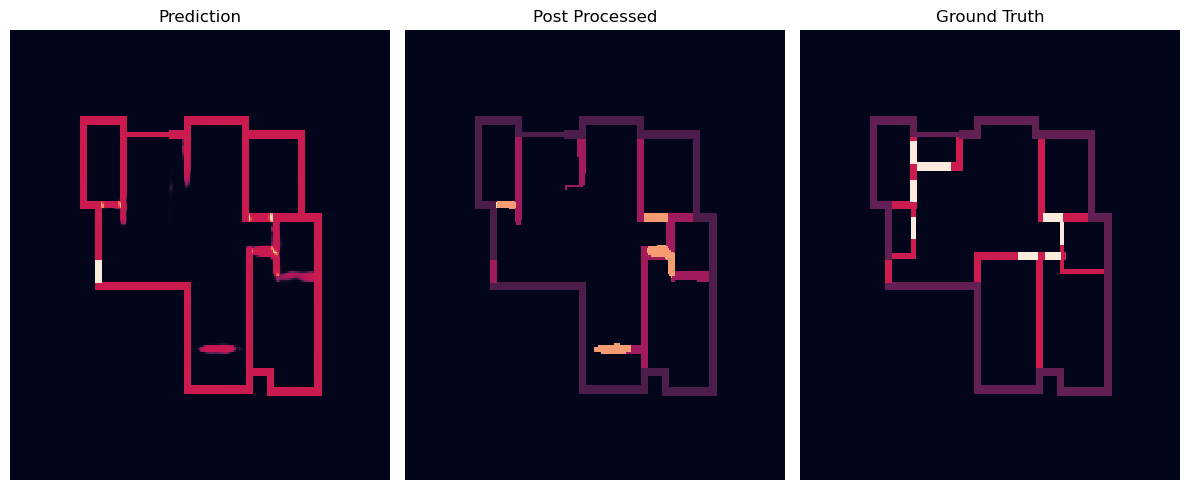

In [57]:
input_arrs = np.sum([boundary_mask_gt, room_mask_gt*2, door_mask_gt*4], axis=0)

pred_room_bin = np.where(pred_room >= 0.20, 1, 0)
pred_door_bin = np.where(pred_door >= 0.15, 1, 0)

stacked_layers_nt = np.sum([pred_room, pred_door], axis=0)
stacked_layers = np.sum([pred_room_bin*2, pred_door_bin*4], axis=0)
stacked_layers[stacked_layers >= 4] = 4

img = stacked_layers.copy().astype(np.uint8)

dilate_kernel = np.ones((5,5), np.uint8)
img = cv.dilate(img, dilate_kernel, iterations = 1)

close_kernel = np.ones((5,5), np.uint8)
img = cv.morphologyEx(img, cv.MORPH_CLOSE, close_kernel, iterations=2)

erode_kernel = np.ones((5,5), np.uint8)
img = cv.erode(img, erode_kernel, iterations = 1)

fig, ax = plt.subplots(1, 3, figsize=(12, 5))

sns.heatmap(np.sum([boundary_mask_gt, stacked_layers_nt], axis=0), ax=ax[0], 
            cbar=False, xticklabels=False, yticklabels=False)
ax[0].set_title("Prediction")

sns.heatmap(np.sum([boundary_mask_gt, img], axis=0), ax=ax[1], 
            cbar=False, xticklabels=False, yticklabels=False)
ax[1].set_title("Post Processed")

sns.heatmap(input_arrs, 
            cbar=False, xticklabels=False, yticklabels=False)
ax[2].set_title("Ground Truth")

plt.tight_layout()
plt.show()